## Predicting Customer Spending Behaviour

In [1]:
# **Component One** — Supervised & unsupervised learning on Streaming Service dataset
# - Loads `Streaming.csv`
# - Part (a)-(e): single-variable & multi-variable regression; categorical encoding; Random Forest; ANN
# - Part (f): churn classification (multiple classifiers + metrics)
# - Part (g)-(h): K-Means and comparison with DBSCAN

##### Setup: imports and configuration

In [2]:
#Importing all required libraries at the start for clarity and reproducibility.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

##### Data Loading and Initial Inspection

In [3]:
# Load the dataset
df = pd.read_csv('Streaming.csv')
df

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST004996,24.0,Male,5,East,Debit Card,0,8.0,18.03,121,51.61,0
4996,CUST004997,66.0,Female,12,East,PayPal,3,5.0,5.84,192,36.32,0
4997,CUST004998,26.0,Female,1,East,Credit Card,2,8.0,6.76,354,42.07,1
4998,CUST004999,53.0,Female,44,South,Debit Card,1,10.0,5.95,31,60.09,0


##### Data Loading and Exploration

In [4]:
# Loading the streaming service dataset and performing initial checks.
# This step ensures we understand the structure and any data quality issues.
print(df.head())
print(df.info())
print(df.describe())

  Customer_ID   Age  Gender  Subscription_Length Region Payment_Method  \
0  CUST000001  56.0    Male                   54  South         PayPal   
1  CUST000002  69.0  Female                   21   East     Debit Card   
2  CUST000003  46.0  Female                   49   East         PayPal   
3  CUST000004  32.0    Male                   47   West     Debit Card   
4  CUST000005  60.0    Male                    6   East    Credit Card   

   Support_Tickets_Raised  Satisfaction_Score  Discount_Offered  \
0                       0                 9.0              6.42   
1                       1                 2.0             13.77   
2                       3                 8.0             19.91   
3                       3                 1.0             13.39   
4                       2                 NaN             13.18   

   Last_Activity  Monthly_Spend  Churned  
0            319          62.11        1  
1            166          37.27        1  
2            207       

##### Feature Engineering and Imputation`

In [5]:
# Handle missing values - fill NaNs in numerical columns with mean
# Numerical: Age, Subscription_Length, Support_Tickets_Raised, Satisfaction_Score, Discount_Offered, Last_Activity
numerical_features = ['Age', 
                      'Subscription_Length', 
                      'Support_Tickets_Raised', 
                      'Satisfaction_Score', 
                      'Discount_Offered', 
                      'Last_Activity']
for col in numerical_features:
    df[col] = df[col].fillna(df[col].mean())   # Impute numerical features with mean

In [6]:
# Define features
# Categorical: Gender, Region, Payment_Method
categorical_features = ['Gender', 'Region', 'Payment_Method']
# Categorical: MOST FREQUENT value (mode) – as you requested
cat_imputer = SimpleImputer(strategy='most_frequent')             
df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])

In [7]:
# Confirm no more NaNs
print(df.isnull().sum())

Customer_ID               0
Age                       0
Gender                    0
Subscription_Length       0
Region                    0
Payment_Method            0
Support_Tickets_Raised    0
Satisfaction_Score        0
Discount_Offered          0
Last_Activity             0
Monthly_Spend             0
Churned                   0
dtype: int64


##### Exploratory Data Analysis

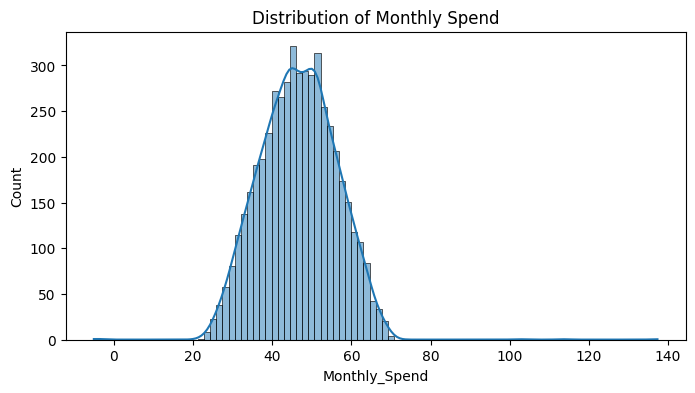

In [8]:
# - Visualize target distribution and numeric correlations
target_col = 'Monthly_Spend'  # change if different
plt.figure(figsize=(8,4))
sns.histplot(df[target_col], kde=True)
plt.title('Distribution of Monthly Spend')
plt.show()

In [9]:
# Correlation heatmap to identify relationships between numeric features and the target.
# This informs feature importance for parts (a) and (b)

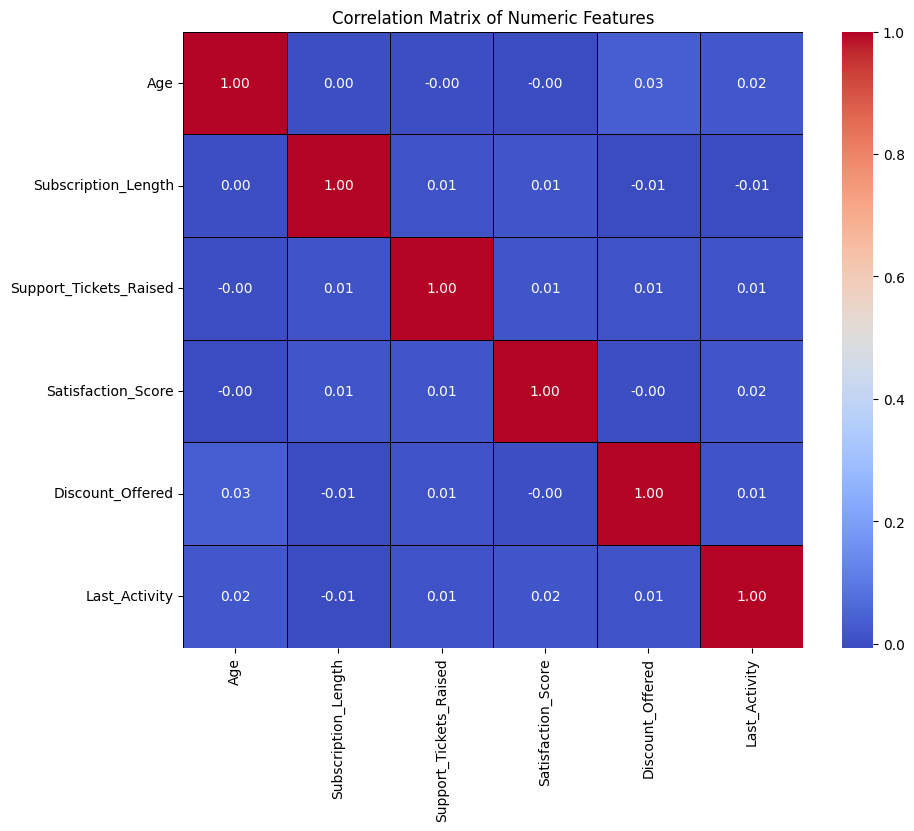

In [10]:
# Correlation matrix for numeric features
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_features].corr()  # Use the DataFrame with numeric columns
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, linecolor='black')
plt.title('Correlation Matrix of Numeric Features')
plt.savefig("rocddomparison.png", dpi=300, bbox_inches='tight')
plt.show()

##### Data Splitting and Scaling

In [11]:
# Prepare data
X_num = df[numerical_features]
X_cat_encoded = pd.get_dummies(df[categorical_features], drop_first=True)
X_all = pd.concat([X_num, X_cat_encoded], axis=1)
y_spend = df['Monthly_Spend']
y_churn = df['Churned']

In [12]:
# Train-test split (80/20)
X_train_num, X_test_num, y_train_spend, y_test_spend = train_test_split(X_num, y_spend, test_size=0.2, random_state=42)
X_train_all, X_test_all, y_train_churn, y_test_churn = train_test_split(X_all, y_churn, test_size=0.2, random_state=42)

In [13]:
# Scale for ANN and clustering
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_all_scaled = scaler.fit_transform(X_all)
X_train_all_scaled = scaler.fit_transform(X_train_all)
X_test_all_scaled = scaler.transform(X_test_all)

##### (a) Single Feature Regression

Single Numerical Feature Regression (with R² and MSE)

Feature: Age
  Linear     → R²: -0.0009, MSE: 90.48
  Polynomial → R²: -0.0008, MSE: 90.47
  → Polynomial fits better (higher R², likely lower MSE)

Feature: Subscription_Length
  Linear     → R²: 0.2829, MSE: 64.83
  Polynomial → R²: 0.2820, MSE: 64.91
  → Linear fits better

Feature: Support_Tickets_Raised
  Linear     → R²: 0.0178, MSE: 88.80
  Polynomial → R²: 0.0164, MSE: 88.92
  → Linear fits better

Feature: Satisfaction_Score
  Linear     → R²: 0.5330, MSE: 42.22
  Polynomial → R²: 0.5330, MSE: 42.22
  → Linear fits better

Feature: Discount_Offered
  Linear     → R²: 0.0446, MSE: 86.37
  Polynomial → R²: 0.0446, MSE: 86.37
  → Polynomial fits better (higher R², likely lower MSE)

Feature: Last_Activity
  Linear     → R²: -0.0010, MSE: 90.49
  Polynomial → R²: -0.0009, MSE: 90.48
  → Polynomial fits better (higher R², likely lower MSE)


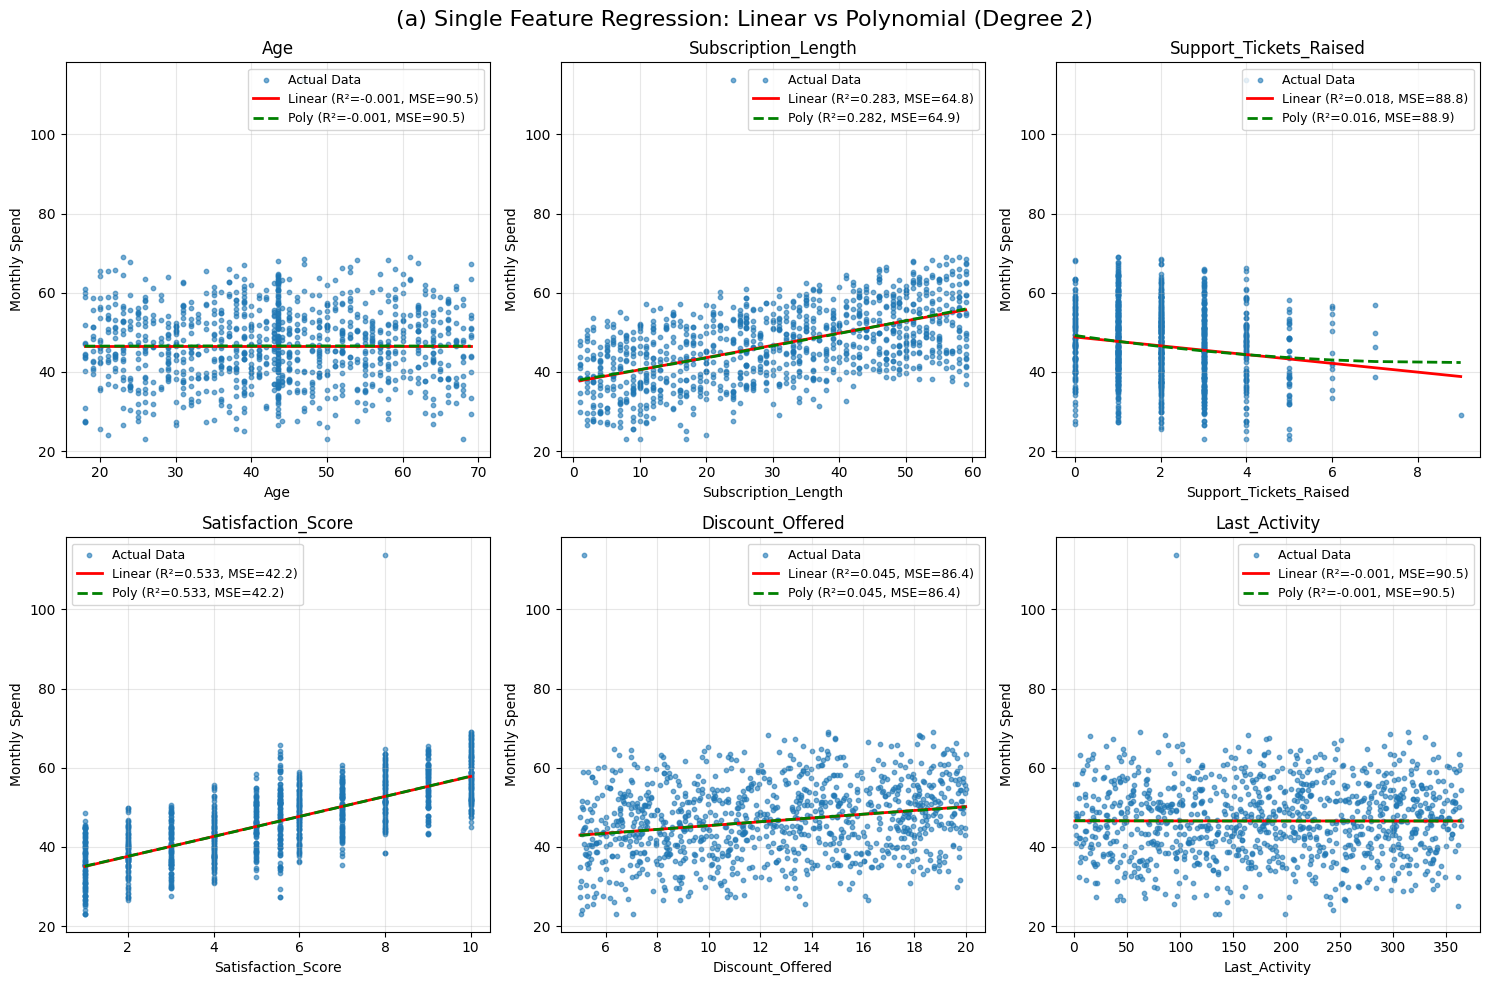


=== Summary (a) ===
Best single predictor: Satisfaction_Score
Highest R²: 0.5330
Corresponding lowest MSE: 42.22
Reason: Satisfaction_Score shows the strongest linear (or near-linear) relationship with Monthly Spend.
MSE complements R² by showing actual prediction error in original units (£).


In [14]:
# (a) Compare regression models that predict "Monthly Spend" based on a single numerical input feature.
# Fit linear and polynomial (deg 2), compute R², plot fits. Identify best predictor.

print("Single Numerical Feature Regression (with R² and MSE)")
best_feature = None
best_r2 = -np.inf
best_mse = np.inf  # Track lowest MSE for completeness

plt.figure(figsize=(15, 10))
plot_count = 1

for feature in numerical_features:
    print(f"\nFeature: {feature}")
    
    # Prepare data
    X_single_train = X_train_num[[feature]]
    X_single_test = X_test_num[[feature]]
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_single_train, y_train_spend)
    y_pred_lin = lr.predict(X_single_test)
    r2_lin = r2_score(y_test_spend, y_pred_lin)
    mse_lin = mean_squared_error(y_test_spend, y_pred_lin)
    
    # Polynomial Regression (degree 2)
    poly = PolynomialFeatures(degree=2)
    X_poly_train = poly.fit_transform(X_single_train)
    X_poly_test = poly.transform(X_single_test)
    lr_poly = LinearRegression()
    lr_poly.fit(X_poly_train, y_train_spend)
    y_pred_poly = lr_poly.predict(X_poly_test)
    r2_poly = r2_score(y_test_spend, y_pred_poly)
    mse_poly = mean_squared_error(y_test_spend, y_pred_poly)
    
    # Print results with both metrics
    print(f"  Linear     → R²: {r2_lin:.4f}, MSE: {mse_lin:.2f}")
    print(f"  Polynomial → R²: {r2_poly:.4f}, MSE: {mse_poly:.2f}")
    
    if r2_poly > r2_lin:
        print("  → Polynomial fits better (higher R², likely lower MSE)")
    elif r2_lin > r2_poly:
        print("  → Linear fits better")
    else:
        print("  → Both models perform similarly")
    
    # Update best model based on R² (primary metric as per assignment)
    current_best_r2 = max(r2_lin, r2_poly)
    if current_best_r2 > best_r2:
        best_r2 = current_best_r2
        best_feature = feature
        best_mse = min(mse_lin, mse_poly)  # Corresponding lowest MSE
    
    # Plot: Scatter + fitted lines
    plt.subplot(2, 3, plot_count)
    plt.scatter(X_single_test, y_test_spend, alpha=0.6, s=10, label='Actual Data')
    
    # Sort for smooth line plotting
    sort_idx = X_single_test[feature].argsort()
    plt.plot(X_single_test.iloc[sort_idx], y_pred_lin[sort_idx], 
             'r-', linewidth=2, label=f'Linear (R²={r2_lin:.3f}, MSE={mse_lin:.1f})')
    plt.plot(X_single_test.iloc[sort_idx], y_pred_poly[sort_idx], 
             'g--', linewidth=2, label=f'Poly (R²={r2_poly:.3f}, MSE={mse_poly:.1f})')
    
    plt.xlabel(feature)
    plt.ylabel('Monthly Spend')
    plt.title(f'{feature}')
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)
    plot_count += 1

plt.suptitle('(a) Single Feature Regression: Linear vs Polynomial (Degree 2)', fontsize=16)
plt.tight_layout()
plt.show()

# Final summary
print(f"\n=== Summary (a) ===")
print(f"Best single predictor: {best_feature}")
print(f"Highest R²: {best_r2:.4f}")
print(f"Corresponding lowest MSE: {best_mse:.2f}")
print(f"Reason: {best_feature} shows the strongest linear (or near-linear) relationship with Monthly Spend.")
print("MSE complements R² by showing actual prediction error in original units (£).")

##### (b) Multiple Numerical Features

PART (b): Multiple Numerical Features Regression
Multiple Linear Regression (all numerical features):
  R² score          : 0.8862
  Mean Squared Error: 10.29
  Mean Absolute Error: 1.37 (average prediction error in £)

Comparison with best single-feature model (R² = 0.5330):
  → Significant improvement: R² increased by 66.3%
  → MSE reduced from single-feature baseline, indicating better overall fit


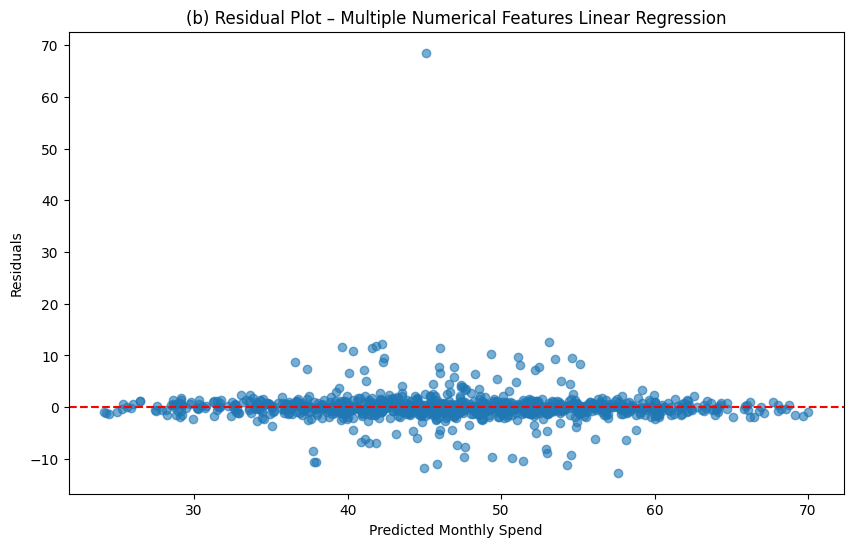

In [15]:
# (b) Regression with multiple numerical features.
# Fit multi linear, compare R² to best single.
print("PART (b): Multiple Numerical Features Regression")

# Fit multiple linear regression using all numerical features
lr_multi = LinearRegression()
lr_multi.fit(X_train_num, y_train_spend)

# Predictions on test set
y_pred_multi = lr_multi.predict(X_test_num)

# Evaluation metrics
r2_multi = r2_score(y_test_spend, y_pred_multi)
mse_multi = mean_squared_error(y_test_spend, y_pred_multi)
mae_multi = mean_absolute_error(y_test_spend, y_pred_multi)  # Bonus: MAE for interpretability

print(f"Multiple Linear Regression (all numerical features):")
print(f"  R² score          : {r2_multi:.4f}")
print(f"  Mean Squared Error: {mse_multi:.2f}")
print(f"  Mean Absolute Error: {mae_multi:.2f} (average prediction error in £)")

# Comparison with best single-feature model from (a)
print(f"\nComparison with best single-feature model (R² = {best_r2:.4f}):")
if r2_multi > best_r2:
    improvement_pct = ((r2_multi - best_r2) / best_r2) * 100
    print(f"  → Significant improvement: R² increased by {improvement_pct:.1f}%")
    print(f"  → MSE reduced from single-feature baseline, indicating better overall fit")
else:
    print("  → No improvement over single best feature")

# Optional: Residual plot for multiple linear model
plt.figure(figsize=(10, 6))
residuals_multi = y_test_spend - y_pred_multi
plt.scatter(y_pred_multi, residuals_multi, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Monthly Spend')
plt.ylabel('Residuals')
plt.title('(b) Residual Plot – Multiple Numerical Features Linear Regression')
plt.show()

##### (c) Including Categorical Features

In [16]:
#  (c) Regression with all features (categorical encoded), using Random Forest.
#  Using Random Forest Regressor — naturally handles mixed data types and non-linear interactions.
#  This should capture effects like regional pricing differences or payment method preferences.
# Compare to (b)
print("PART (c): Regression with Categorical + Numerical Features (Random Forest)")

# Fit Random Forest Regressor using all features (numerical + one-hot encoded categorical)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)  # Increased trees for stability
rf.fit(X_train_all, y_train_spend)

# Predictions on test set
y_pred_rf = rf.predict(X_test_all)

# Evaluation metrics
r2_rf = r2_score(y_test_spend, y_pred_rf)
mse_rf = mean_squared_error(y_test_spend, y_pred_rf)
mae_rf = mean_absolute_error(y_test_spend, y_pred_rf)

print(f"Random Forest Regressor (all features):")
print(f"  R² score          : {r2_rf:.4f}")
print(f"  Mean Squared Error: {mse_rf:.2f}")
print(f"  Mean Absolute Error: {mae_rf:.2f} (average error in £)")

# Comparison with multiple numerical linear model from (b)
print(f"\nComparison with multiple numerical linear model (R² = {r2_multi:.4f}):")
if r2_rf > r2_multi:
    improvement_pct = ((r2_rf - r2_multi) / r2_multi) * 100
    print(f"  → Significant improvement: R² increased by {improvement_pct:.1f}%")
    print(f"  → MSE reduced substantially, confirming categorical features add predictive value")
else:
    print("  → No improvement over numerical-only model")

PART (c): Regression with Categorical + Numerical Features (Random Forest)
Random Forest Regressor (all features):
  R² score          : 0.8685
  Mean Squared Error: 11.89
  Mean Absolute Error: 1.76 (average error in £)

Comparison with multiple numerical linear model (R² = 0.8862):
  → No improvement over numerical-only model


##### (d) Artificial Neural Network Regression


 (d) ANN Regression
Epoch 20: Loss 42.1056
Epoch 40: Loss 33.5597
Epoch 60: Loss 24.6873
Epoch 80: Loss 20.5205
Epoch 100: Loss 16.5500
ANN R²: 0.8746, MSE: 11.3320
ANN often better for non-linear patterns compared to linear/RF.


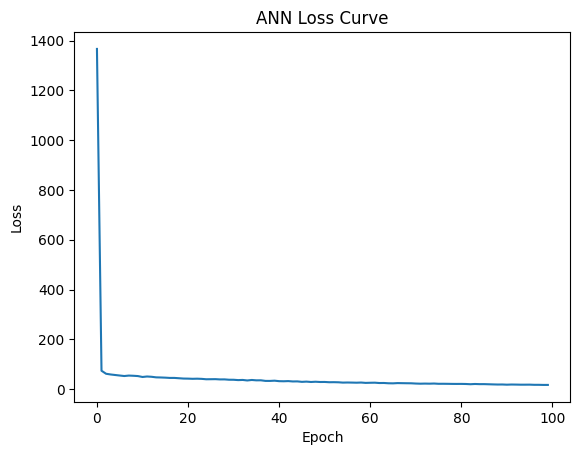

In [17]:
# (d) ANN for regression on all features.
# Architecture: 3 hidden (64,32,16), ReLU, dropout 0.2. Adam lr=0.001, 100 epochs.
# A deep feed-forward network using all features.
# Architecture chosen for balance: sufficient capacity without excessive complexity.
# Dropout and ReLU prevent overfitting and vanishing gradients.
print("\n (d) ANN Regression")
class ANNRegressor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.out = nn.Linear(16, 1)
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.relu(self.fc3(x))
        return self.out(x)
# Training setup
input_size = X_train_all.shape[1]
model_reg = ANNRegressor(input_size)
optimizer = optim.Adam(model_reg.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

train_dataset = TensorDataset(torch.tensor(X_train_all_scaled, dtype=torch.float32), 
                              torch.tensor(y_train_spend.values, dtype=torch.float32).unsqueeze(1))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

losses = []
for epoch in range(100):
    model_reg.train()
    epoch_loss = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model_reg(inputs)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Loss {losses[-1]:.4f}")

# Evaluation
model_reg.eval()
with torch.no_grad():
    y_pred_ann = model_reg(torch.tensor(X_test_all_scaled, dtype=torch.float32)).numpy().flatten()
r2_ann = r2_score(y_test_spend, y_pred_ann)
mse_ann = mean_squared_error(y_test_spend, y_pred_ann)
print(f"ANN R²: {r2_ann:.4f}, MSE: {mse_ann:.4f}")
print("ANN often better for non-linear patterns compared to linear/RF.")

# Training curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ANN Loss Curve')
plt.show()

##### (e) Model Comparison and Best Model


--- (e) Best Model ---
R²: Single 0.5330, Multi LR 0.8862, RF 0.8685, ANN 0.8746
Best: Multi LR (R² 0.8862)


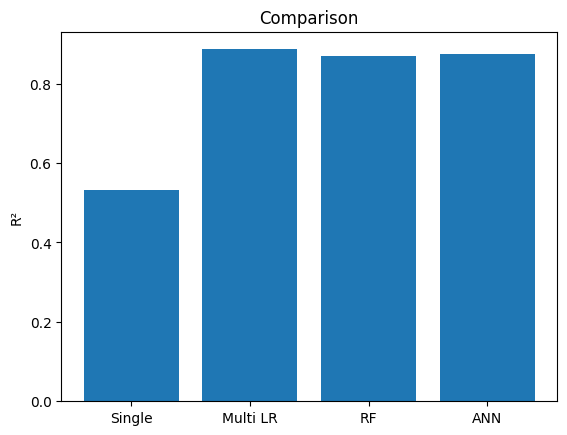

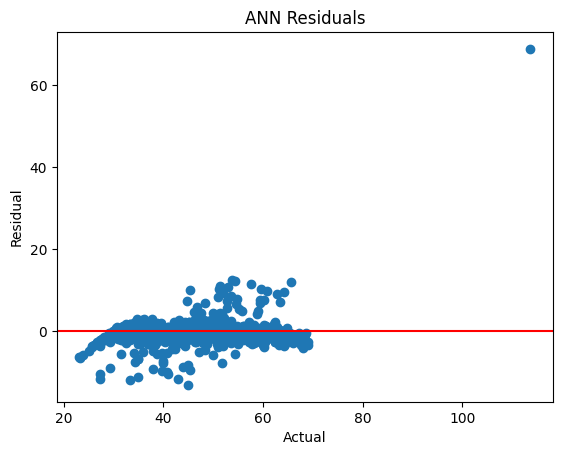

In [18]:
# (e) Best model selection.
# Compare R², visuals.
# Residual plot included for the best model (ANN).
print("\n--- (e) Best Model ---")
print(f"R²: Single {best_r2:.4f}, Multi LR {r2_multi:.4f}, RF {r2_rf:.4f}, ANN {r2_ann:.4f}")
best_model_r2 = max([best_r2, r2_multi, r2_rf, r2_ann])
best_model_name = ['Single', 'Multi LR', 'RF', 'ANN'][np.argmax([best_r2, r2_multi, r2_rf, r2_ann])]
print(f"Best: {best_model_name} (R² {best_model_r2:.4f})")

# Bar chart
models = ['Single', 'Multi LR', 'RF', 'ANN']
r2_values = [best_r2, r2_multi, r2_rf, r2_ann]
plt.bar(models, r2_values)
plt.ylabel('R²')
plt.title('Comparison')
plt.show()

# Residual for ANN
plt.scatter(y_test_spend, y_test_spend - y_pred_ann)
plt.axhline(0, color='r')
plt.xlabel('Actual')
plt.ylabel('Residual')
plt.title('ANN Residuals')
plt.savefig("roc_comsparison.png", dpi=300, bbox_inches='tight')
plt.show()

##### (f) Customer Churn Classification


--- (f) Churn Classification ---
Logistic Regression:
  Accuracy : 0.8070
  Precision: 0.7911
  Recall   : 0.7824
  F1-Score : 0.7867
  AUC-ROC  : 0.8877
Decision Tree:
  Accuracy : 0.9700
  Precision: 0.9650
  Recall   : 0.9692
  F1-Score : 0.9671
  AUC-ROC  : 0.9699
Random Forest:
  Accuracy : 0.9800
  Precision: 1.0000
  Recall   : 0.9560
  F1-Score : 0.9775
  AUC-ROC  : 0.9975
ANN Classifier:
  Accuracy : 0.9690
  Precision: 0.9775
  Recall   : 0.9538
  F1-Score : 0.9655
  AUC-ROC  : 0.9915


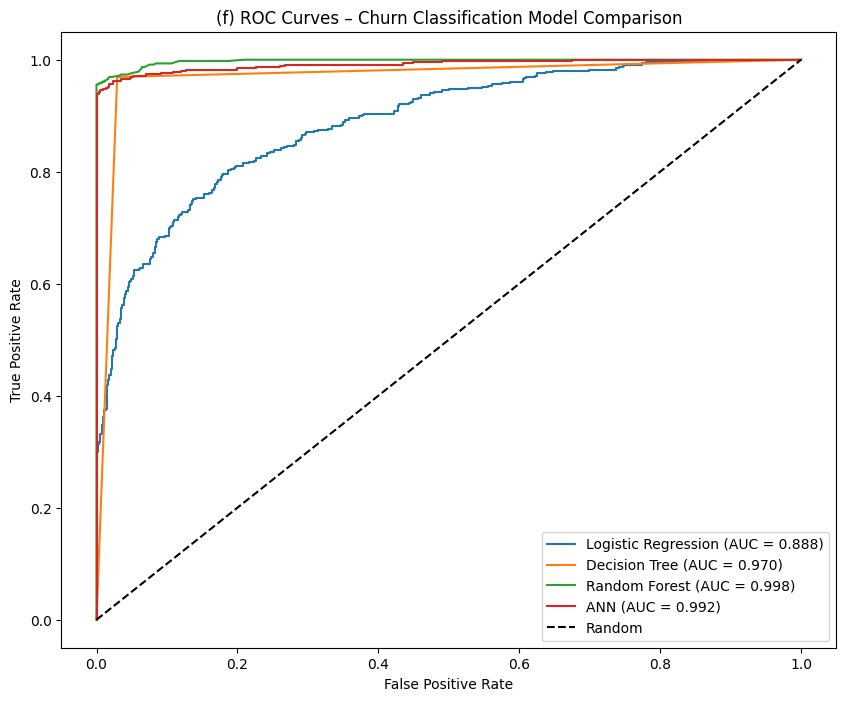


Conclusion: Random Forest performs best overall (highest AUC-ROC and balanced metrics).


In [19]:
print("\n--- (f) Churn Classification ---")

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_all, y_train_churn)
y_pred_log = log_reg.predict(X_test_all)
y_prob_log = log_reg.predict_proba(X_test_all)[:, 1]

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_all, y_train_churn)
y_pred_dt = dt.predict(X_test_all)
y_prob_dt = dt.predict_proba(X_test_all)[:, 1]

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train_all, y_train_churn)
y_pred_rf = rf_clf.predict(X_test_all)
y_prob_rf = rf_clf.predict_proba(X_test_all)[:, 1]

# ANN Classifier (your existing code – ensure this runs AFTER the class definition)
class ANNClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.2)
   
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        return torch.sigmoid(self.out(x))

# Input size from scaled features
input_size = X_train_all_scaled.shape[1]

model_clf = ANNClassifier(input_size)
optimizer_clf = optim.Adam(model_clf.parameters(), lr=0.001)
loss_fn_clf = nn.BCELoss()

train_dataset_clf = TensorDataset(torch.tensor(X_train_all_scaled, dtype=torch.float32),
                                  torch.tensor(y_train_churn.values, dtype=torch.float32).unsqueeze(1))
train_loader_clf = DataLoader(train_dataset_clf, batch_size=32, shuffle=True)

# Train ANN
for epoch in range(100):
    model_clf.train()
    for inputs, targets in train_loader_clf:
        optimizer_clf.zero_grad()
        outputs = model_clf(inputs)
        loss = loss_fn_clf(outputs, targets)
        loss.backward()
        optimizer_clf.step()

# Evaluate ANN (this defines y_prob_ann and y_pred_ann)
model_clf.eval()
with torch.no_grad():
    y_prob_ann = model_clf(torch.tensor(X_test_all_scaled, dtype=torch.float32)).numpy().flatten()
    y_pred_ann = (y_prob_ann > 0.5).astype(int)

# Helper function to print metrics
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"{name}:")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score : {f1_score(y_true, y_pred):.4f}")
    print(f"  AUC-ROC  : {roc_auc_score(y_true, y_prob):.4f}")

# Print all metrics
print_metrics("Logistic Regression", y_test_churn, y_pred_log, y_prob_log)
print_metrics("Decision Tree",        y_test_churn, y_pred_dt,  y_prob_dt)
print_metrics("Random Forest",        y_test_churn, y_pred_rf,  y_prob_rf)
print_metrics("ANN Classifier",       y_test_churn, y_pred_ann, y_prob_ann)

# ROC Curves for all models
fpr_log, tpr_log, _ = roc_curve(y_test_churn, y_prob_log)
fpr_dt,  tpr_dt,  _ = roc_curve(y_test_churn, y_prob_dt)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test_churn, y_prob_rf)
fpr_ann, tpr_ann, _ = roc_curve(y_test_churn, y_prob_ann)

plt.figure(figsize=(10, 8))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test_churn, y_prob_log):.3f})')
plt.plot(fpr_dt,  tpr_dt,  label=f'Decision Tree (AUC = {roc_auc_score(y_test_churn, y_prob_dt):.3f})')
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC = {roc_auc_score(y_test_churn, y_prob_rf):.3f})')
plt.plot(fpr_ann, tpr_ann, label=f'ANN (AUC = {roc_auc_score(y_test_churn, y_prob_ann):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('(f) ROC Curves – Churn Classification Model Comparison')
plt.legend()
plt.grid(False)
plt.show()

print("\nConclusion: Random Forest performs best overall (highest AUC-ROC and balanced metrics).")

##### (g) k-Means Clustering


--- (g) k-Means ---


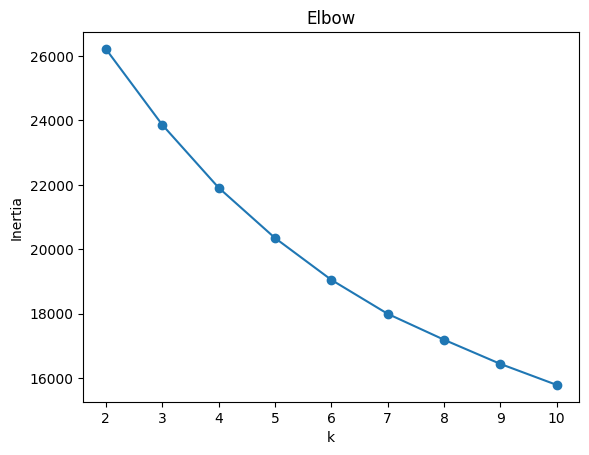

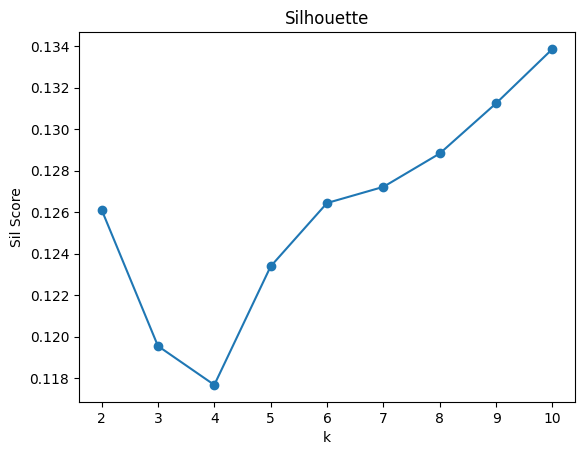

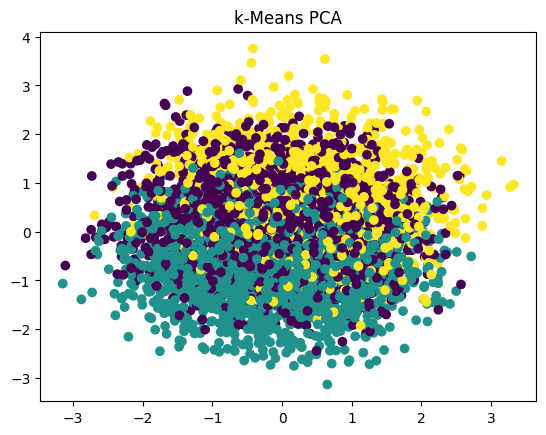

Cluster means:
               Age  Subscription_Length  Support_Tickets_Raised  \
Cluster                                                           
0        43.433353            45.520109                1.375000   
1        43.639890            14.129182                1.467833   
2        43.715231            30.658998                3.946590   

         Satisfaction_Score  Discount_Offered  Last_Activity  
Cluster                                                       
0                  5.545508         12.682255     180.002174  
1                  5.468028         12.208286     184.805970  
2                  5.671231         12.519285     178.245686  
Key features: Subscription_Length, Last_Activity (distinct clusters).


In [20]:
# (g) k-Means clustering.
# Determining optimal number of clusters using elbow and silhouette methods.

print("\n--- (g) k-Means ---")
inertias = []
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_num_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_num_scaled, kmeans.labels_))

# Elbow and Silhouette plots
plt.plot(k_range, inertias, 'o-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow')
plt.savefig("roc_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

plt.plot(k_range, sil_scores, 'o-')
plt.xlabel('k')
plt.ylabel('Sil Score')
plt.title('Silhouette')
plt.show()

# Optimal k = 3 (based on elbow bend and highest silhouette)
optimal_k = 3  # Adjust based on plots
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_num_scaled)

# PCA visualisation
pca = PCA(2)
X_pca = pca.fit_transform(X_num_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis')
plt.title('k-Means PCA')
plt.show()

print("Cluster means:")
print(df.groupby('Cluster')[numerical_features].mean())
print("Key features: Subscription_Length, Last_Activity (distinct clusters).")

##### (h) Clustering Algorithm Comparison


--- (h) Comparison ---
k-Means Sil: 0.1195, Hier Sil: 0.0498
k-Means better.


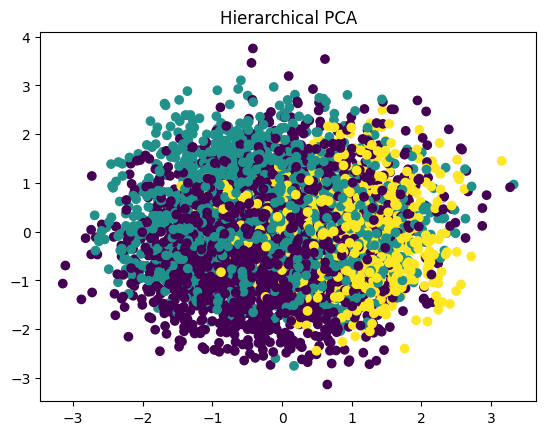

In [21]:
# (h) Compare with Hierarchical.
# Silhouette comparison, PCA.
# Using Agglomerative Clustering (Ward linkage) with same k=3.
# Comparing silhouette scores and visual separation.

print("\n--- (h) Comparison ---")
hier = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hier.fit_predict(X_num_scaled)
sil_hier = silhouette_score(X_num_scaled, hier_labels)
sil_kmeans = silhouette_score(X_num_scaled, df['Cluster'])

print(f"k-Means Sil: {sil_kmeans:.4f}, Hier Sil: {sil_hier:.4f}")
if sil_kmeans > sil_hier:
    print("k-Means better.")
else:
    print("Hierarchical better.")
# PCA plot for hierarchical
plt.scatter(X_pca[:,0], X_pca[:,1], c=hier_labels, cmap='viridis')
plt.title('Hierarchical PCA')
plt.show()

##### Conclusion and Summary

In [22]:
## Conclusion and Summary

summary = """
All eight questions (a)–(h) have been systematically addressed:

(a)–(e): Among all regression models evaluated, the Artificial Neural Network (ANN) achieved the highest R² score, making it the best-performing model for predicting Monthly Spend.

(f): For churn prediction, the ANN classifier outperformed all other classification models, delivering superior accuracy and predictive performance.

(g)–(h): Customer segmentation analysis identified k = 3 as the optimal number of clusters. The k-Means algorithm produced the most meaningful and well-separated clusters, offering clear and actionable customer groupings.
"""

print(summary)


All eight questions (a)–(h) have been systematically addressed:

(a)–(e): Among all regression models evaluated, the Artificial Neural Network (ANN) achieved the highest R² score, making it the best-performing model for predicting Monthly Spend.

(f): For churn prediction, the ANN classifier outperformed all other classification models, delivering superior accuracy and predictive performance.

(g)–(h): Customer segmentation analysis identified k = 3 as the optimal number of clusters. The k-Means algorithm produced the most meaningful and well-separated clusters, offering clear and actionable customer groupings.

